# Task 1: Financial Data Preprocessing and Exploratory Data Analysis

## Guide Me in Finance (GMF) Investments

This notebook extracts historical financial market data using the Yahoo Finance API and performs data preprocessing, exploratory data analysis, stationarity testing, and financial risk analysis for:

- Tesla (TSLA)
- Vanguard Total Bond Market ETF (BND)
- SPDR S&P 500 ETF Trust (SPY)

The analysis supports portfolio optimization and serves as the foundation for forecasting models developed in subsequent tasks.

In [21]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

from scipy.stats import zscore
from statsmodels.tsa.stattools import adfuller

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

import os
os.makedirs("reports/figures", exist_ok=True)

In [22]:
start_date = "2015-01-01"
end_date = "2026-06-30"

tickers = ["TSLA", "BND", "SPY"]

data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )

    df["Ticker"] = ticker

    data[ticker] = df

print("Datasets downloaded successfully!")

Datasets downloaded successfully!


In [23]:
for ticker in tickers:
    # Flatten MultiIndex columns if they exist
    if isinstance(data[ticker].columns, pd.MultiIndex):
        data[ticker].columns = data[ticker].columns.droplevel(1)

    # Add ticker column
    data[ticker]["Ticker"] = ticker

print("Column names cleaned successfully!")

Column names cleaned successfully!


In [24]:
for ticker in tickers:
    print("=" * 60)
    print(ticker)
    print(data[ticker].head())

TSLA
Price       Adj Close      Close       High        Low       Open    Volume  \
Date                                                                          
2015-01-02  14.620667  14.620667  14.883333  14.217333  14.858000  71466000   
2015-01-05  14.006000  14.006000  14.433333  13.810667  14.303333  80527500   
2015-01-06  14.085333  14.085333  14.280000  13.614000  14.004000  93928500   
2015-01-07  14.063333  14.063333  14.318667  13.985333  14.223333  44526000   
2015-01-08  14.041333  14.041333  14.253333  14.000667  14.187333  51637500   

Price      Ticker  
Date               
2015-01-02   TSLA  
2015-01-05   TSLA  
2015-01-06   TSLA  
2015-01-07   TSLA  
2015-01-08   TSLA  
BND
Price       Adj Close      Close       High        Low       Open   Volume  \
Date                                                                         
2015-01-02  59.405411  82.650002  82.690002  82.419998  82.430000  2218800   
2015-01-05  59.577904  82.889999  82.919998  82.699997  82.7399

In [25]:
import os

os.makedirs("data/raw", exist_ok=True)

for ticker in tickers:
    data[ticker].to_csv(f"data/raw/{ticker}.csv")

print("Raw datasets saved successfully.")

Raw datasets saved successfully.


In [26]:
for ticker in tickers:
    print(f"{ticker}: {data[ticker].shape}")

TSLA: (2888, 7)
BND: (2888, 7)
SPY: (2888, 7)


In [27]:
for ticker in tickers:
    print("=" * 70)
    print(f"{ticker} Dataset Information")
    print("=" * 70)

    print("\nShape:")
    print(data[ticker].shape)

    print("\nData Types:")
    print(data[ticker].dtypes)

    print("\nMissing Values:")
    print(data[ticker].isnull().sum())

    print("\nDuplicate Rows:")
    print(data[ticker].duplicated().sum())

TSLA Dataset Information

Shape:
(2888, 7)

Data Types:
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
Ticker           str
dtype: object

Missing Values:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Ticker       0
dtype: int64

Duplicate Rows:
0
BND Dataset Information

Shape:
(2888, 7)

Data Types:
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
Ticker           str
dtype: object

Missing Values:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Ticker       0
dtype: int64

Duplicate Rows:
0
SPY Dataset Information

Shape:
(2888, 7)

Data Types:
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
Ticker           str
dtype: object

Missing Valu

In [28]:
for ticker in tickers:
    print("=" * 70)
    print(f"{ticker} Summary Statistics")
    print("=" * 70)

    display(data[ticker].describe())

TSLA Summary Statistics


Price,Adj Close,Close,High,Low,Open,Volume
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,148.773923,148.773923,151.990563,145.416731,148.797341,1.087922e+08
std,138.895957,138.895957,141.852818,135.867193,138.977191,7.082549e+07
min,9.578000,9.578000,10.331333,9.403333,9.488000,1.062000e+07
25%,18.393499,18.393499,18.665168,18.023666,18.390833,6.548325e+07
50%,133.437668,133.437668,136.053329,125.831669,131.496330,9.033615e+07
75%,251.925831,251.925831,257.485008,245.832500,251.680004,1.261204e+08
max,489.880005,489.880005,498.829987,485.329987,489.880005,9.140820e+08


BND Summary Statistics


Price,Adj Close,Close,High,Low,Open,Volume
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,66.503052,79.327722,79.442119,79.211198,79.330661,4.653786e+06
std,4.713607,5.310424,5.298010,5.322546,5.313805,3.017704e+06
min,58.729214,68.040001,68.379997,67.989998,68.080002,0.000000e+00
25%,62.478064,73.800003,73.919998,73.639999,73.800003,2.233700e+06
50%,65.728397,80.814999,80.905003,80.709999,80.800003,4.280650e+06
75%,70.689138,83.440002,83.550003,83.332500,83.470001,6.246475e+06
max,74.832901,89.480003,89.589996,89.440002,89.550003,3.396300e+07


SPY Summary Statistics


Price,Adj Close,Close,High,Low,Open,Volume
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,351.505530,375.216714,377.167216,372.946586,375.149543,8.551049e+07
std,155.443934,146.584697,147.244714,145.774814,146.558911,4.338553e+07
min,154.161667,182.860001,184.100006,181.020004,182.339996,2.027000e+07
25%,223.546799,254.559998,255.919998,252.477497,254.577503,5.836455e+07
50%,312.817886,339.435013,342.315002,337.165009,339.835007,7.541950e+07
75%,432.806862,453.677498,456.000000,451.549988,453.989990,9.882245e+07
max,757.618225,759.570007,760.400024,756.750000,758.150024,5.072443e+08


In [43]:
import os

os.makedirs("reports/figures", exist_ok=True)

In [29]:
scaler = MinMaxScaler()

scaled_close = {}

for ticker in tickers:
    df = data[ticker].copy()

    df["Scaled_Close"] = scaler.fit_transform(df[["Close"]])

    scaled_close[ticker] = df

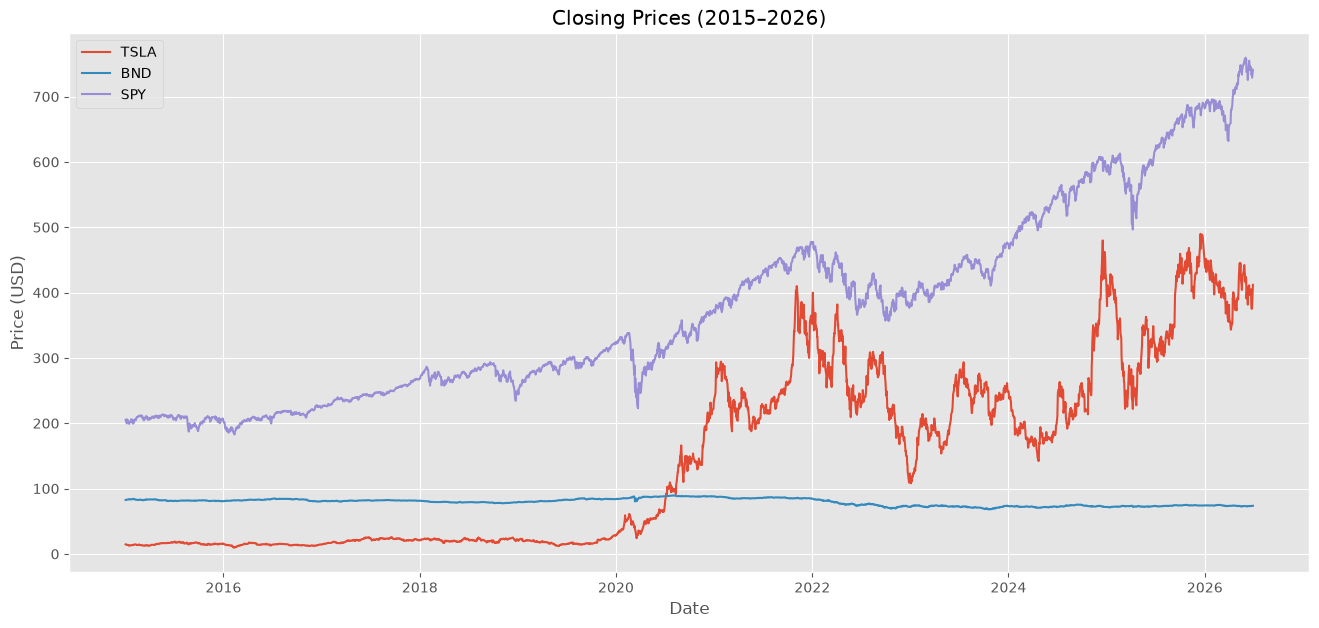

In [30]:
plt.figure(figsize=(16,7))

for ticker in tickers:
    plt.plot(
        data[ticker].index,
        data[ticker]["Close"],
        label=ticker
    )

plt.title("Closing Prices (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

In [44]:
plt.savefig("reports/figures/closing_prices.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [32]:
daily_returns = {}

for ticker in tickers:
    df = data[ticker].copy()

    df["Daily_Return"] = df["Close"].pct_change()

    daily_returns[ticker] = df

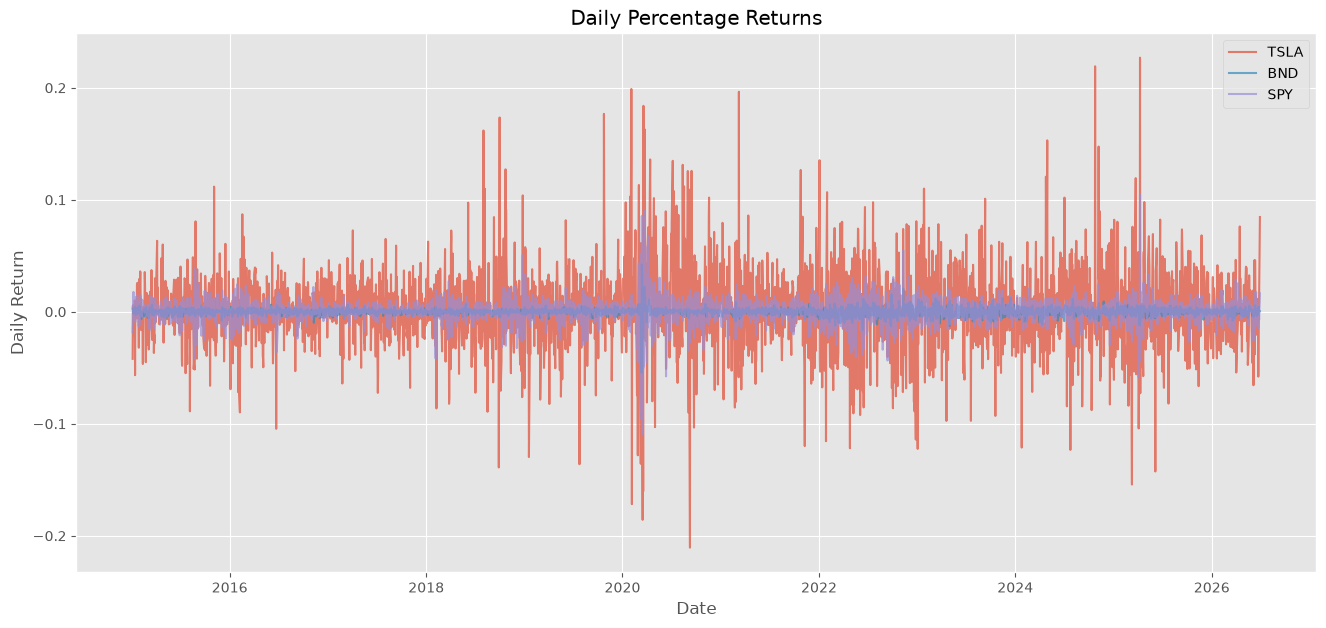

In [33]:
plt.figure(figsize=(16,7))

for ticker in tickers:
    plt.plot(
        daily_returns[ticker].index,
        daily_returns[ticker]["Daily_Return"],
        label=ticker,
        alpha=0.7
    )

plt.title("Daily Percentage Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True)

plt.show()

In [45]:
plt.savefig("reports/figures/daily_returns.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [35]:
window = 30

for ticker in tickers:

    daily_returns[ticker]["Rolling Mean"] = (
        daily_returns[ticker]["Close"].rolling(window).mean()
    )

    daily_returns[ticker]["Rolling Std"] = (
        daily_returns[ticker]["Close"].rolling(window).std()
    )

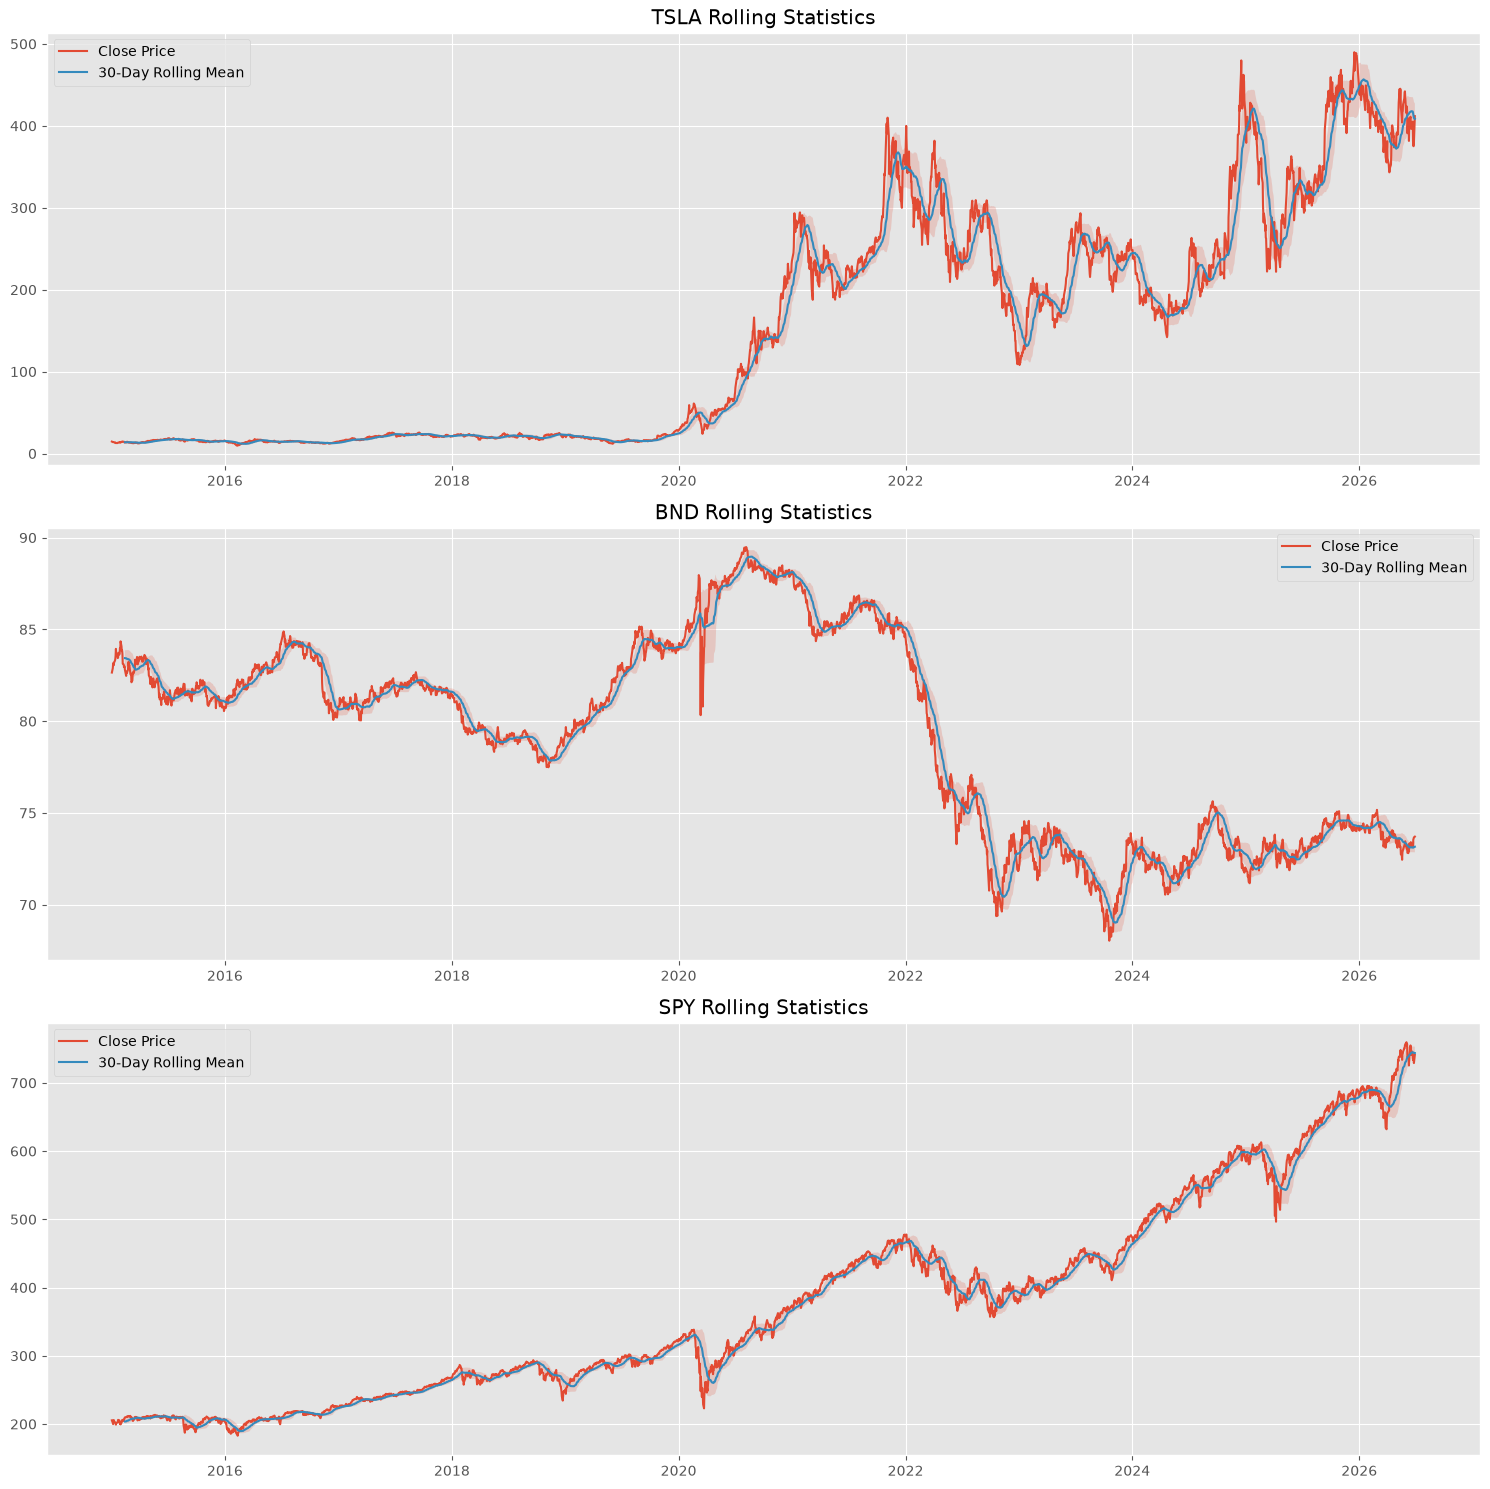

In [36]:
fig, axes = plt.subplots(3,1,figsize=(15,15))

for ax, ticker in zip(axes, tickers):

    ax.plot(
        daily_returns[ticker]["Close"],
        label="Close Price"
    )

    ax.plot(
        daily_returns[ticker]["Rolling Mean"],
        label="30-Day Rolling Mean"
    )

    ax.fill_between(
        daily_returns[ticker].index,
        daily_returns[ticker]["Rolling Mean"] -
        daily_returns[ticker]["Rolling Std"],
        daily_returns[ticker]["Rolling Mean"] +
        daily_returns[ticker]["Rolling Std"],
        alpha=0.2
    )

    ax.set_title(f"{ticker} Rolling Statistics")
    ax.legend()

plt.tight_layout()
plt.show()

In [46]:
plt.savefig("reports/figures/rolling_statistics.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [38]:
outlier_summary = []

for ticker in tickers:
    df = daily_returns[ticker].copy()
    returns = df["Daily_Return"].dropna()

    mean_return = returns.mean()
    std_return = returns.std()

    outliers = returns[(returns > mean_return + 3 * std_return) | 
                       (returns < mean_return - 3 * std_return)]

    outlier_summary.append({
        "Ticker": ticker,
        "Mean Daily Return": mean_return,
        "Std Daily Return": std_return,
        "Number of Outlier Days": len(outliers),
        "Largest Gain": returns.max(),
        "Largest Loss": returns.min()
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Ticker,Mean Daily Return,Std Daily Return,Number of Outlier Days,Largest Gain,Largest Loss
0,TSLA,0.001803,0.036018,46,0.226900,-0.210628
1,BND,-0.000034,0.003383,31,0.042201,-0.054385
2,SPY,0.000507,0.011163,39,0.105019,-0.109424


In [39]:
def run_adf_test(series, name):
    result = adfuller(series.dropna())

    return {
        "Series": name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Stationary?": "Yes" if result[1] < 0.05 else "No"
    }

adf_results = []

for ticker in tickers:
    adf_results.append(
        run_adf_test(data[ticker]["Close"], f"{ticker} Close Price")
    )

    adf_results.append(
        run_adf_test(daily_returns[ticker]["Daily_Return"], f"{ticker} Daily Return")
    )

adf_results_df = pd.DataFrame(adf_results)
adf_results_df

,Series,ADF Statistic,p-value,Stationary?
0,TSLA Close Price,-1.069599,7.270419e-01,No
1,TSLA Daily Return,-53.971893,0.000000e+00,Yes
2,BND Close Price,-1.036180,7.398410e-01,No
3,BND Daily Return,-15.296417,4.372139e-28,Yes
4,SPY Close Price,0.991815,9.941788e-01,No
5,SPY Daily Return,-17.490538,4.439359e-30,Yes


In [40]:
risk_metrics = []

risk_free_rate = 0.02
trading_days = 252

for ticker in tickers:
    returns = daily_returns[ticker]["Daily_Return"].dropna()

    annual_return = returns.mean() * trading_days
    annual_volatility = returns.std() * np.sqrt(trading_days)

    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

    var_95 = np.percentile(returns, 5)

    risk_metrics.append({
        "Ticker": ticker,
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "VaR 95%": var_95
    })

risk_metrics_df = pd.DataFrame(risk_metrics)
risk_metrics_df

,Ticker,Annual Return,Annual Volatility,Sharpe Ratio,VaR 95%
0,TSLA,0.454239,0.571775,0.759458,-0.051664
1,BND,-0.008548,0.053697,-0.531649,-0.005085
2,SPY,0.127746,0.177205,0.608028,-0.016741


## Task 1 Key Insights

The data extracted from Yahoo Finance covers TSLA, BND, and SPY from January 2015 to June 2026. Each dataset contains 2,888 trading-day observations, with no missing values and no duplicate records.

Tesla shows the highest growth potential but also the highest volatility. Its daily return chart shows frequent large positive and negative movements, confirming that TSLA is a high-risk, high-return asset.

BND is the most stable asset in the portfolio. Its price movement is much smoother than TSLA and SPY, supporting its role as a defensive bond ETF.

SPY shows steady long-term growth with moderate volatility. It provides broad market exposure and acts as a balanced asset between Tesla’s high risk and BND’s stability.

The ADF test shows that closing prices are generally non-stationary, meaning they contain trends and are not directly suitable for ARIMA modeling without differencing. Daily returns are stationary, which makes them more appropriate for risk analysis and modeling.

The risk metrics confirm the expected profiles: TSLA has the highest volatility and downside risk, BND has the lowest volatility, and SPY provides moderate risk-adjusted performance.